## K-Means Clustering

K-Means clustering is an unsupervised machine learning algorithm used to partition a dataset into K distinct, non-overlapping subsets (clusters). The goal is to group similar data points together while maximizing the distance between different clusters.

KMeans works by iteratively assigning data points to the nearest cluster centroid and then recalculating the centroids based on the assigned points. The process continues until the centroids no longer change significantly or a maximum number of iterations is reached.

In [17]:
import numpy as np
import random

In [18]:
def kmeans(data, k, max_iters=100, tolerance=1e-4):
    # Step 1: Initialize centroids randomly from the data points
    n_samples = data.shape[0]
    random_indices = np.random.choice(n_samples, k, replace=False)
    centroids = data[random_indices]

    for i in range(max_iters):
        # Step 2: Compute Euclidean distances using NumPy broadcasting
        # (N, 1, 2) - (1, K, 2) -> (N, K, 2) -> sum/sqrt -> (N, K)
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)

        # Step 3: Assign points to nearest centroid
        labels = np.argmin(distances, axis=1)

        # Step 4: Calculate new centroids
        new_centroids = np.array([data[labels == j].mean(axis=0)
        if np.any(labels == j) else data[np.random.choice(n_samples)]
                                  for j in range(k)])

        # Step 5: Check for convergence
        if np.linalg.norm(new_centroids - centroids) < tolerance:
            break
        centroids = new_centroids

    return centroids, labels

In [19]:
import matplotlib.pyplot as plt

def plot_clusters(data, centroids, labels):
    """
    Plots the data points colored by cluster and the corresponding centroids.
    """
    k = len(centroids)
    plt.figure(figsize=(8, 6))

    # Use a colormap to ensure colors match between points and centroids
    cmap = plt.cm.get_cmap('viridis', k)

    # Plot data points
    scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap, s=30, alpha=0.6)

    # Plot centroids with matching colors
    # We map 0..k-1 to the colormap colors
    for i in range(k):
        plt.scatter(centroids[i, 0], centroids[i, 1],
                    color=cmap(i), marker='x', s=200,
                    linewidths=4, edgecolors='black')

    plt.title(f'K-Means Clustering Result (K={k})')
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [20]:
# Generate 200 random samples in 2D space
np.random.seed(42)
data = np.random.rand(200, 2) * 100

# Print the first 20
print(data[:20])

[[37.45401188 95.07143064]
 [73.19939418 59.86584842]
 [15.60186404 15.59945203]
 [ 5.80836122 86.61761458]
 [60.11150117 70.80725778]
 [ 2.05844943 96.99098522]
 [83.24426408 21.23391107]
 [18.18249672 18.34045099]
 [30.4242243  52.47564316]
 [43.19450186 29.12291402]
 [61.18528947 13.94938607]
 [29.21446485 36.63618433]
 [45.60699842 78.51759614]
 [19.96737822 51.42344384]
 [59.24145689  4.64504127]
 [60.75448519 17.05241237]
 [ 6.5051593  94.88855373]
 [96.56320331 80.83973481]
 [30.46137692  9.7672114 ]
 [68.42330265 44.01524937]]


/tmp/ipykernel_2895/478702255.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', k)
/tmp/ipykernel_2895/478702255.py:19: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(centroids[i, 0], centroids[i, 1],


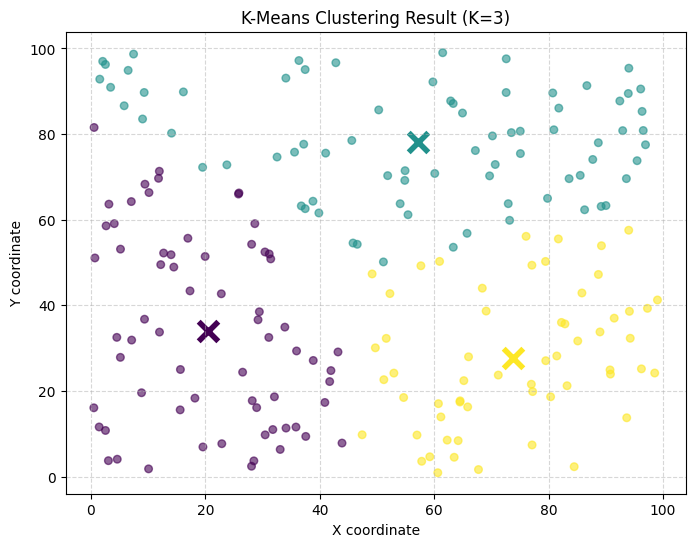

In [21]:
# KMeans for K=3
c, l = kmeans(data, 3)
plot_clusters(data, c, l)

/tmp/ipykernel_2895/478702255.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', k)
/tmp/ipykernel_2895/478702255.py:19: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(centroids[i, 0], centroids[i, 1],


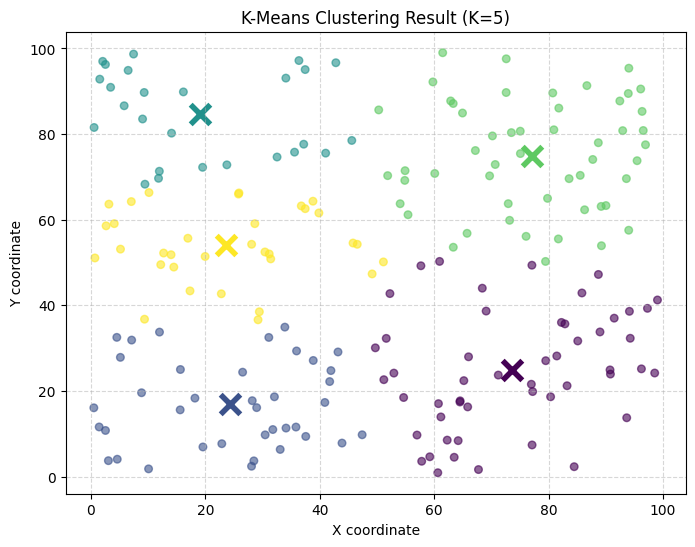

In [22]:
# KMeans for K=5
c, l = kmeans(data, 5)
plot_clusters(data, c, l)

/tmp/ipykernel_2895/478702255.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', k)
/tmp/ipykernel_2895/478702255.py:19: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(centroids[i, 0], centroids[i, 1],


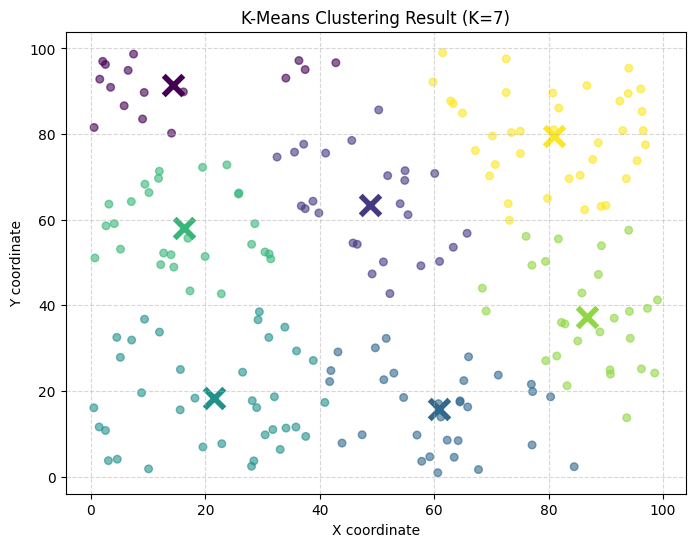

In [23]:
# KMeans for K=7
c, l = kmeans(data, 7)
plot_clusters(data, c, l)

/tmp/ipykernel_2895/478702255.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', k)
/tmp/ipykernel_2895/478702255.py:19: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(centroids[i, 0], centroids[i, 1],


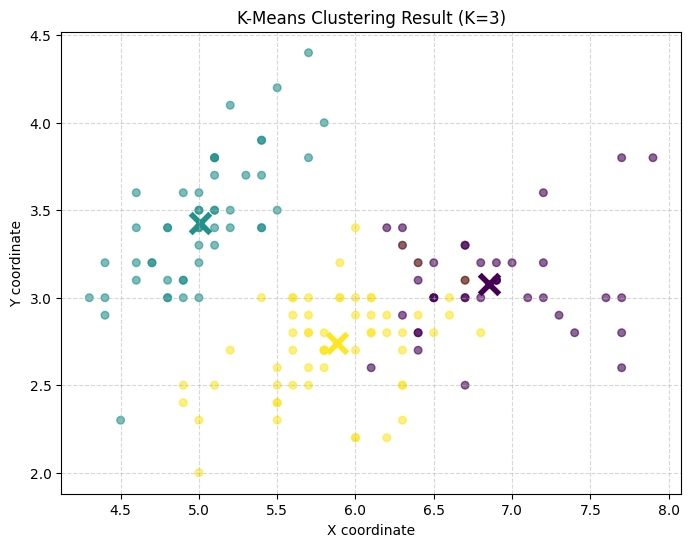

In [24]:
# Extra: Use the Iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
data = iris.data

c, l = kmeans(data, 3)
plot_clusters(data, c, l)